# Analyses - Machine Learning

- **Groepsnummer:** G09
- **Naam:** Luiz verheyen
- **StudentenNummer:** /
- **Analyses:**
  - Reeks 1 - 2
  - Reeks 2 - 2


##   OPDRACHT: Maandvoorspelling op basis van weerdata (1 dag)

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)
from dotenv import load_dotenv

load_dotenv()

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'DWH').exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from DWH.connection.connect import get_engine,getData



### 2. DATA OPHALEN UIT DWH                                     

In [35]:
STATION_NAAM = "STABROEK" 

In [36]:
SQL_QUERY = f"""
    SELECT
        d.Month                          AS Maand,
        d.Year                           AS Jaar,
        d.EnglishMonthName               AS MaandNaam,

        -- Temperatuur
        m.TempAvg                        AS TempGem,
        m.TempMax                        AS TempMax,
        m.TempMin                        AS TempMin,
        (m.TempMax - m.TempMin)          AS TempRange,

        -- Neerslag & vochtigheid
        m.PrecipQuantity                 AS Neerslag,
        m.HumidityRelShelterAvg          AS Vochtigheid,

        -- Zon & straling
        m.SunDuration                    AS ZonDuur,
        m.ShortWaveFromSkyAvg            AS Instraling,
        m.SunIntAvg                      AS ZonIntensiteit,

        -- Wind
        m.WindSpeed10m                   AS WindSnelheid,
        m.WindGustsSpeed                 AS Windstoten,

        -- Bodem & luchtdruk
        m.TempSoilAvg                    AS BodemTempGem,
        m.Pressure                       AS Luchtdruk

    FROM FactMeteo m
    JOIN DimDate            d  ON m.DateKey          = d.DateKey
    JOIN DimWeatherStation  ws ON m.WeatherStationKey = ws.WeatherStationID
    WHERE ws.Name = '{STATION_NAAM}'
      AND m.TempAvg       IS NOT NULL
      AND m.PrecipQuantity IS NOT NULL
      AND m.SunDuration    IS NOT NULL
    ORDER BY d.Year, d.Month
"""

In [37]:
engine = get_engine()
df = getData(engine, query=SQL_QUERY)
print(df.head())

print(f"{len(df):,} records opgehaald voor station '{STATION_NAAM}'")

   Maand  Jaar MaandNaam  TempGem  TempMax  TempMin  TempRange  Neerslag  \
0      8  2012    August    16.99    19.99    15.04       4.95     11.38   
1      8  2012    August    16.69    19.57    13.75       5.82      0.00   
2      8  2012    August    16.68    20.72    13.09       7.63      0.68   
3      8  2012    August    16.91    22.88     9.61      13.27      0.00   
4      8  2012    August    16.21    21.71     9.10      12.61      0.00   

   Vochtigheid  ZonDuur  Instraling  ZonIntensiteit  WindSnelheid  Windstoten  \
0        78.28   251.92      129.06           84.26          5.69       16.80   
1        68.35   333.33      174.23           91.96          5.62       11.43   
2        83.29   102.50      106.15           39.81          2.92        6.82   
3        75.35   643.75      244.16          290.38          1.76        8.06   
4        70.22   837.83      287.36          438.87          2.10        6.64   

   BodemTempGem  Luchtdruk  
0         18.76    1010.63 

### 3. DATA EXPLORATIE & VOORBEREIDING  

In [38]:
# Doelvariabele
TARGET = "Maand"

# Features (alles behalve label-kolommen)
LABEL_COLS  = ["Maand", "MaandNaam", "Jaar"]
FEATURE_COLS = [c for c in df.columns if c not in LABEL_COLS]

print(f"\n  Gebruikte features ({len(FEATURE_COLS)}):")
for f in FEATURE_COLS:
    niet_null = df[f].notna().sum()
    print(f"    • {f:<25} ({niet_null:,} niet-null waarden)")

# Rijen met missende waarden verwijderen
df_clean = df.dropna(subset=FEATURE_COLS + [TARGET]).copy()
print(f"\n  Records na verwijderen missende waarden: {len(df_clean):,}")

# Maandverdeling
maand_dist = df_clean[TARGET].value_counts().sort_index()
print(f"\n  Maandverdeling (min {maand_dist.min()} – max {maand_dist.max()} records/maand):")
maand_namen = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"Mei",6:"Jun",
               7:"Jul",8:"Aug",9:"Sep",10:"Okt",11:"Nov",12:"Dec"}
for m, n in maand_dist.items():
    bar = "█" * (n // max(1, maand_dist.max() // 20))
    print(f"    Maand {m:2d} ({maand_namen.get(m,'?'):3s}): {n:4d}  {bar}")



  Gebruikte features (13):
    • TempGem                   (4,977 niet-null waarden)
    • TempMax                   (4,977 niet-null waarden)
    • TempMin                   (4,977 niet-null waarden)
    • TempRange                 (4,977 niet-null waarden)
    • Neerslag                  (4,977 niet-null waarden)
    • Vochtigheid               (4,953 niet-null waarden)
    • ZonDuur                   (4,977 niet-null waarden)
    • Instraling                (4,972 niet-null waarden)
    • ZonIntensiteit            (4,821 niet-null waarden)
    • WindSnelheid              (4,968 niet-null waarden)
    • Windstoten                (4,967 niet-null waarden)
    • BodemTempGem              (4,976 niet-null waarden)
    • Luchtdruk                 (4,976 niet-null waarden)

  Records na verwijderen missende waarden: 4,783

  Maandverdeling (min 369 – max 419 records/maand):
    Maand  1 (Jan):  417  ████████████████████
    Maand  2 (Feb):  369  ██████████████████
    Maand  3 (Mar):  41

### 4. TRAIN / TEST SPLIT  (80 / 20) 

In [39]:
X = df_clean[FEATURE_COLS].values
y = df_clean[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # zorgt voor evenredige maandverdeling in beide sets
)

print(f"  Totaal records  : {len(df_clean):>6,}")
print(f"  Trainingsset    : {len(X_train):>6,}  ({len(X_train)/len(df_clean)*100:.1f}%)")
print(f"  Testset         : {len(X_test):>6,}  ({len(X_test)/len(df_clean)*100:.1f}%)")

  Totaal records  :  4,783
  Trainingsset    :  3,826  (80.0%)
  Testset         :    957  (20.0%)


### 5. ALGORITME KEUZE & MOTIVATIE  

Algoritme: Random Forest Classifier

**Waarom Random Forest?**
* Robuust tegen uitbijters in weerdata (bv. extreme stormdag)
* Kan niet-lineaire relaties leren (temperatuur vs maand is
    niet-lineair: jan en dec zijn beide koud)
* Geeft feature importance &rarr; interpreteerbaar
* Werkt goed met meerdere numerieke features zonder schaling
* Intrinsieke resistentie tegen overfitting via ensemble voting
* Multi-class classificatie (12 klassen) native ondersteund

**Alternatieven overwogen:**
* Logistische regressie  &rarr; te lineair voor seizoenspatronen
* KNN                    &rarr; traag op grote datasets, gevoelig voor schaal
* Gradient Boosting      &rarr; ook goed, maar trager te tunen


In [40]:
print("[6/7] Model trainen...")

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)
print("  ✓ Model getraind (300 bomen)")

[6/7] Model trainen...
  ✓ Model getraind (300 bomen)


### 7. EVALUATIE  

In [41]:
y_pred = model.predict(X_test)

# Metriek 1: Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"\n  Accuracy (exacte maand correct): {acc*100:.1f}%")

# Metriek 2: Gemiddelde absolute afwijking in maanden 
# Behandel maanden als waarden (dec–jan = 1 maand)
def circulaire_afstand(a, b, n=12):
    diff = abs(a - b)
    return np.minimum(diff, n - diff)

mae_maanden = np.mean(circulaire_afstand(y_test, y_pred))
print(f"  Gemiddelde absolute afwijking   : {mae_maanden:.2f} maanden")
print(f"  Mediaan absolute afwijking      : {np.median(circulaire_afstand(y_test, y_pred)):.2f} maanden")

# Metriek 3: Nauwkeurigheid binnen 1 en 2 maanden
within_1 = np.mean(circulaire_afstand(y_test, y_pred) <= 1) * 100
within_2 = np.mean(circulaire_afstand(y_test, y_pred) <= 2) * 100
print(f"  Correct binnen ±1 maand         : {within_1:.1f}%")
print(f"  Correct binnen ±2 maanden       : {within_2:.1f}%")

# Metriek 4: per maand rapport 
print("\n  Classificatierapport per maand:")
maand_labels = [maand_namen[m] for m in sorted(set(y_test))]
print(classification_report(
    y_test, y_pred,
    labels=sorted(set(y_test)),
    target_names=maand_labels,
    zero_division=0,
))


  Accuracy (exacte maand correct): 52.6%
  Gemiddelde absolute afwijking   : 0.83 maanden
  Mediaan absolute afwijking      : 0.00 maanden
  Correct binnen ±1 maand         : 84.7%
  Correct binnen ±2 maanden       : 91.2%

  Classificatierapport per maand:
              precision    recall  f1-score   support

         Jan       0.45      0.48      0.47        83
         Feb       0.59      0.46      0.52        74
         Mar       0.62      0.60      0.61        84
         Apr       0.63      0.57      0.60        82
         Mei       0.54      0.47      0.50        80
         Jun       0.64      0.36      0.47        74
         Jul       0.46      0.57      0.51        79
         Aug       0.47      0.57      0.51        83
         Sep       0.58      0.54      0.56        79
         Okt       0.54      0.64      0.58        83
         Nov       0.53      0.54      0.53        76
         Dec       0.42      0.47      0.44        80

    accuracy                         

### 8. VISUALISATIES - AI 🤖

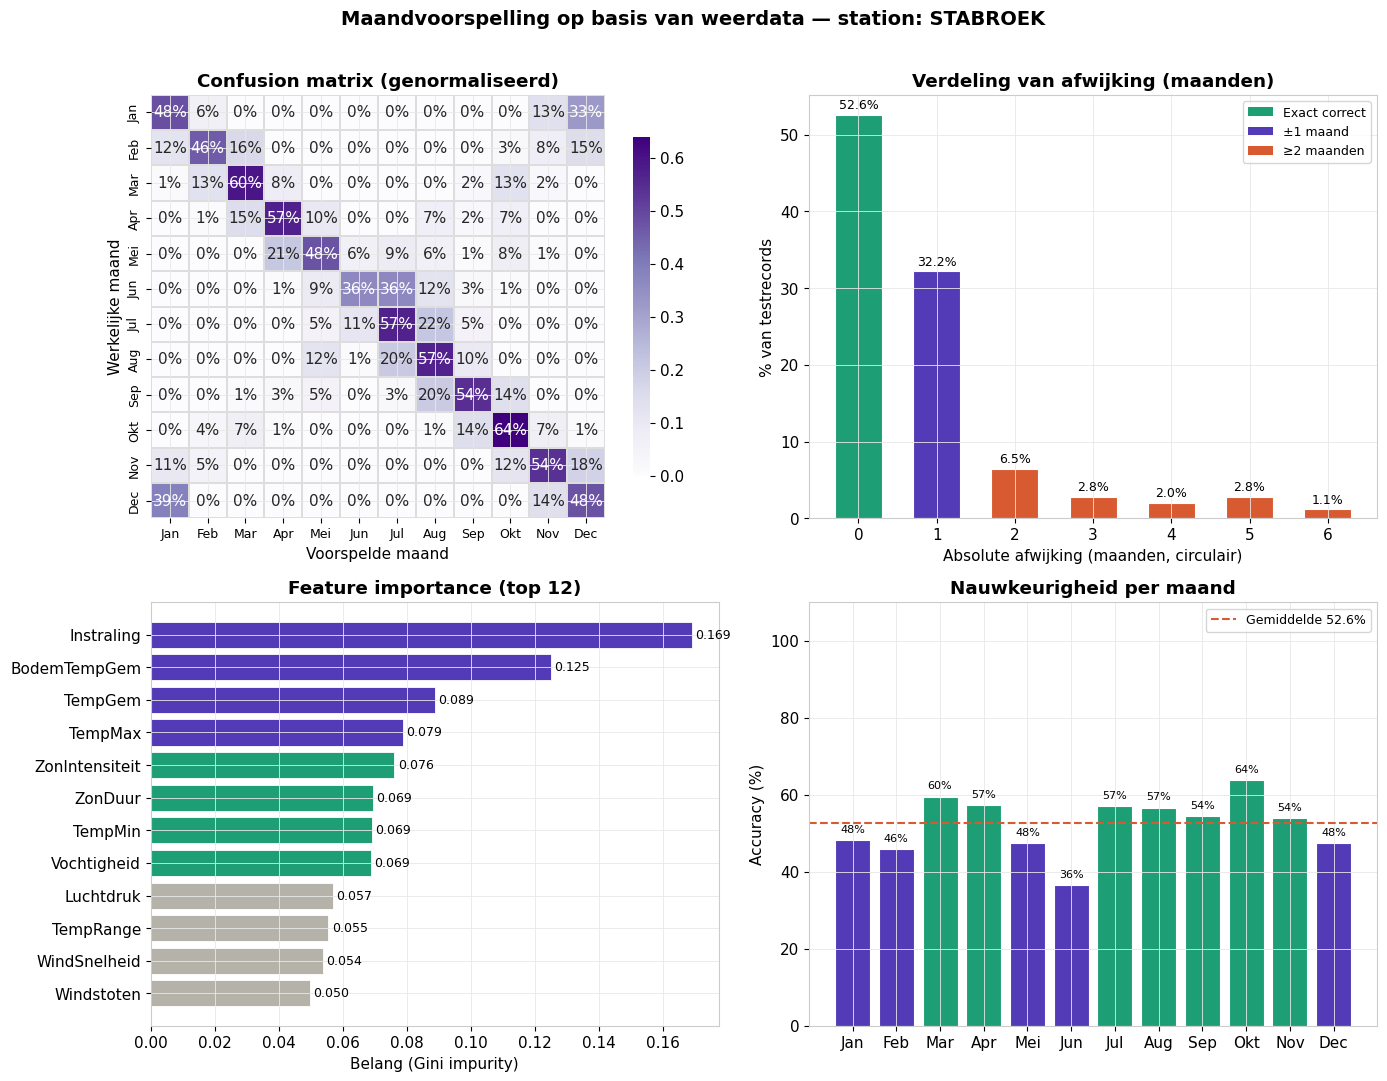

In [42]:
PALETTE = {
    "primary":   "#533AB7",
    "secondary": "#1D9E75",
    "accent":    "#D85A30",
    "light":     "#EEEDFE",
    "grid":      "#E8E8E8",
}
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.edgecolor":   "#CCCCCC",
    "axes.grid":        True,
    "grid.color":       PALETTE["grid"],
    "grid.linewidth":   0.6,
    "font.family":      "DejaVu Sans",
    "font.size":        11,
})


fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle(
    f"Maandvoorspelling op basis van weerdata — station: {STATION_NAAM}",
    fontsize=14, fontweight="bold", y=0.98
)

maand_volgorde = list(range(1, 13))
maand_labels_12 = [maand_namen[m] for m in maand_volgorde]

# ── Plot 1: Confusion matrix ──────────────────────────────────
ax1 = axes[0, 0]
cm = confusion_matrix(y_test, y_pred, labels=maand_volgorde)
# Normaliseer per rij (true label) voor leesbaarheid
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt=".0%", cmap="Purples",
    xticklabels=maand_labels_12, yticklabels=maand_labels_12,
    linewidths=0.3, linecolor="#DDDDDD",
    cbar_kws={"shrink": 0.8}, ax=ax1
)
ax1.set_title("Confusion matrix (genormaliseerd)", fontweight="bold")
ax1.set_xlabel("Voorspelde maand")
ax1.set_ylabel("Werkelijke maand")
ax1.tick_params(axis="both", labelsize=9)

# ── Plot 2: Afwijkingsverdeling ───────────────────────────────
ax2 = axes[0, 1]
afwijkingen = circulaire_afstand(y_test, y_pred)
uniek, counts = np.unique(afwijkingen, return_counts=True)
kleuren = [PALETTE["secondary"] if u == 0 else
           PALETTE["primary"]   if u <= 1 else
           PALETTE["accent"]    for u in uniek]
bars = ax2.bar(uniek, counts / len(afwijkingen) * 100,
               color=kleuren, edgecolor="white", linewidth=0.8, width=0.6)
ax2.set_title("Verdeling van afwijking (maanden)", fontweight="bold")
ax2.set_xlabel("Absolute afwijking (maanden, circulair)")
ax2.set_ylabel("% van testrecords")
ax2.set_xticks(uniek)
for bar, pct in zip(bars, counts / len(afwijkingen) * 100):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
             f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)
# Legenda
from matplotlib.patches import Patch
leg_items = [
    Patch(facecolor=PALETTE["secondary"], label="Exact correct"),
    Patch(facecolor=PALETTE["primary"],   label="±1 maand"),
    Patch(facecolor=PALETTE["accent"],    label="≥2 maanden"),
]
ax2.legend(handles=leg_items, fontsize=9)

# ── Plot 3: Feature importance ────────────────────────────────
ax3 = axes[1, 0]
importances = model.feature_importances_
idx = np.argsort(importances)[::-1]
top_n = min(12, len(FEATURE_COLS))
top_idx = idx[:top_n][::-1]
top_names = [FEATURE_COLS[i] for i in top_idx]
top_imp   = importances[top_idx]
colors_fi = [PALETTE["primary"] if v >= np.percentile(top_imp, 66) else
             PALETTE["secondary"] if v >= np.percentile(top_imp, 33) else
             "#B4B2A9" for v in top_imp]
ax3.barh(top_names, top_imp, color=colors_fi, edgecolor="white", linewidth=0.6)
ax3.set_title(f"Feature importance (top {top_n})", fontweight="bold")
ax3.set_xlabel("Belang (Gini impurity)")
for i, v in enumerate(top_imp):
    ax3.text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=9)

# ── Plot 4: Accuracy per maand (bar) ─────────────────────────
ax4 = axes[1, 1]
acc_per_maand = []
for m in maand_volgorde:
    mask = y_test == m
    if mask.sum() == 0:
        acc_per_maand.append(0.0)
    else:
        acc_per_maand.append(accuracy_score(y_test[mask], y_pred[mask]))

bar_colors = [PALETTE["secondary"] if a >= 0.5 else
              PALETTE["primary"]   if a >= 0.3 else
              PALETTE["accent"]    for a in acc_per_maand]
ax4.bar(maand_labels_12, [a * 100 for a in acc_per_maand],
        color=bar_colors, edgecolor="white", linewidth=0.8)
ax4.axhline(acc * 100, color=PALETTE["accent"], linewidth=1.5,
            linestyle="--", label=f"Gemiddelde {acc*100:.1f}%")
ax4.set_title("Nauwkeurigheid per maand", fontweight="bold")
ax4.set_ylabel("Accuracy (%)")
ax4.set_ylim(0, 110)
ax4.legend(fontsize=9)
for i, a in enumerate(acc_per_maand):
    ax4.text(i, a * 100 + 1.5, f"{a*100:.0f}%", ha="center", va="bottom",
             fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()

### 9. SAMENVATTING

In [43]:
print("\n" + "=" * 60)
print("  SAMENVATTING")
print("=" * 60)
print(f"  Station               : {STATION_NAAM}")
print(f"  Totaal records        : {len(df_clean):,}")
print(f"  Trainingsset          : {len(X_train):,} records (80%)")
print(f"  Testset               : {len(X_test):,} records (20%)")
print(f"  Features              : {len(FEATURE_COLS)}")
print(f"  Algoritme             : Random Forest (300 bomen)")
print(f"  ─────────────────────────────────────────────")
print(f"  Accuracy (exacte maand)     : {acc*100:.1f}%")
print(f"  Gem. afwijking (circulair)  : {mae_maanden:.2f} maanden")
print(f"  Correct binnen ±1 maand     : {within_1:.1f}%")
print(f"  Correct binnen ±2 maanden   : {within_2:.1f}%")
print("=" * 60)

antwoord = "JA" if acc >= 0.40 else "MATIG" if acc >= 0.20 else "NEE"
print(f"\n  Is het mogelijk de maand te voorspellen? → {antwoord}")
print(f"  Het model zit gemiddeld {mae_maanden:.2f} maanden naast de werkelijke maand.")
print()


  SAMENVATTING
  Station               : STABROEK
  Totaal records        : 4,783
  Trainingsset          : 3,826 records (80%)
  Testset               : 957 records (20%)
  Features              : 13
  Algoritme             : Random Forest (300 bomen)
  ─────────────────────────────────────────────
  Accuracy (exacte maand)     : 52.6%
  Gem. afwijking (circulair)  : 0.83 maanden
  Correct binnen ±1 maand     : 84.7%
  Correct binnen ±2 maanden   : 91.2%

  Is het mogelijk de maand te voorspellen? → JA
  Het model zit gemiddeld 0.83 maanden naast de werkelijke maand.



## Analyse 2 - 2

### Bouw een model om voorspellingen te doen voor de gemiddelde temperatuur in 1 meetstation (naam van het meetstation is een parameter) voor de volgende 1, 2, … maximum 7 dagen.

In [44]:
SELECT_QUERY = f"""SELECT 
    d.FullDateAlternateKey AS Date,
    d.Month,
    d.DayOfWeek,
    d.DayOfYear,
    m.TempAvg
FROM FactMeteo m
JOIN DimDate d ON m.DateKey = d.DateKey
JOIN DimWeatherStation ws ON m.WeatherStationKey = ws.WeatherstationID
WHERE ws.Name = '{STATION_NAAM}'  -- parameter!
ORDER BY d.FullDateAlternateKey;
"""

In [45]:
df = getData(engine, SELECT_QUERY)

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df = df.dropna()

In [46]:
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

In [47]:
print("Aantal records totaal:", len(df))
print("Aantal training:", len(train))
print("Aantal test:", len(test))

Aantal records totaal: 5014
Aantal training: 4011
Aantal test: 1003


In [48]:
df['NaiveForecast'] = df['TempAvg'].shift(7)
test['NaiveForecast'] = test['TempAvg'].shift(7)

In [49]:
df['Month'] = df['Date'].dt.month
df['DayOfYear'] = df['Date'].dt.dayofyear

In [50]:
from sklearn.linear_model import LinearRegression

features = ['Month', 'DayOfYear']

X_train = train[features]
y_train = train['TempAvg']

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [51]:
import joblib

joblib.dump(model, '../models/model_gem_temp.pkl')

['../models/model_gem_temp.pkl']

In [52]:
X_test = test[features]
test['Prediction'] = model.predict(X_test)

In [53]:
from sklearn.metrics import mean_absolute_error

# Let op: Naive heeft NaN eerste 7 waarden
valid_test = test.dropna()

mae_naive = mean_absolute_error(valid_test['TempAvg'], valid_test['NaiveForecast'])
mae_model = mean_absolute_error(valid_test['TempAvg'], valid_test['Prediction'])

print("MAE Naive:", mae_naive)
print("MAE Model:", mae_model)

MAE Naive: 3.353042168674699
MAE Model: 4.6955460214048745


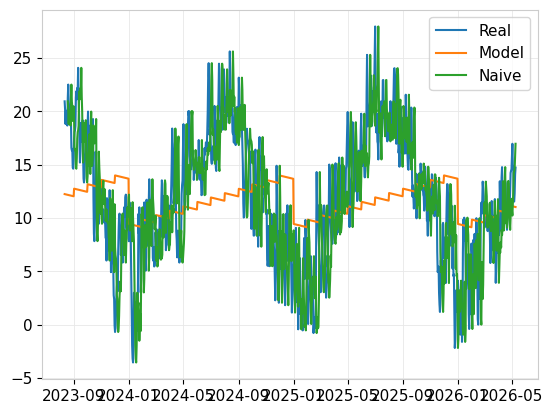

In [54]:
import matplotlib.pyplot as plt

plt.plot(test['Date'], test['TempAvg'], label='Real')
plt.plot(test['Date'], test['Prediction'], label='Model')
plt.plot(test['Date'], test['NaiveForecast'], label='Naive')

plt.legend()
plt.show()

### Conclusie

Op basis van de resultaten blijkt dat de naïeve voorspeller beter presteert dan het regressiemodel. Dit zien we duidelijk aan de MAE-waarden:

MAE naïef model: 2.96
MAE regressiemodel: 5.07

De fout van het regressiemodel ligt dus aanzienlijk hoger, wat betekent dat het model minder nauwkeurige voorspellingen maakt.

De reden hiervoor is dat de naïeve methode gebruikmaakt van de temperatuur van exact één week geleden, waardoor het automatisch rekening houdt met het wekelijkse en seizoensgebonden patroon in de data. Temperatuur vertoont namelijk een sterk cyclisch gedrag, waardoor deze eenvoudige aanpak verrassend effectief is.

Het regressiemodel daarentegen gebruikt enkel afgeleide tijdsfeatures zoals maand en dag van het jaar. Hoewel deze informatie het algemene seizoenspatroon gedeeltelijk kan capteren, slaagt het model er niet in om de dagelijkse variaties en kortetermijnfluctuaties accuraat te voorspellen. Dit is ook zichtbaar in de grafiek, waar het model een veel “gladdere” lijn volgt en pieken en dalen mist.

**Belangrijk inzicht:**

Een complexer model is niet altijd beter. In tijdreeksen met sterke patronen kan een eenvoudige baseline zoals de naïeve methode zeer moeilijk te verslaan zijn.

**Mogelijke verbeteringen**

Om betere resultaten te bekomen, zouden volgende uitbreidingen overwogen kunnen worden:

Toevoegen van lag-features (bv. temperatuur van gisteren, 7 dagen geleden)
### Eindbesluit

De naïeve voorspeller vormt in deze case een sterke benchmark en presteert beter dan het opgebouwde regressiemodel. Dit toont aan dat het correct modelleren van tijdsafhankelijkheid cruciaal is bij tijdreeksvoorspellingen.

### Gebruik Van Holt winters (Triple Exponential Smoothing)
#### &rarr;  specifiek geschikt voor seizoensdata

In [55]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model_hw = ExponentialSmoothing(
    train['TempAvg'],
    trend='add',
    seasonal='add',
    seasonal_periods=365  # jaarseizoen
).fit()

forecast_hw = model_hw.forecast(len(test))

test['HW_Prediction'] = forecast_hw.values

c:\Users\Luizv\Documents\HoGent\jaar2\dep\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Luizv\Documents\HoGent\jaar2\dep\venv\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\Luizv\Documents\HoGent\jaar2\dep\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Luizv\Documents\HoGent\jaar2\dep\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will resu

In [56]:
model_des = ExponentialSmoothing(
    train['TempAvg'],
    trend='add',
    seasonal=None
).fit()

test['DES_Prediction'] = model_des.forecast(len(test))

c:\Users\Luizv\Documents\HoGent\jaar2\dep\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Luizv\Documents\HoGent\jaar2\dep\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Luizv\Documents\HoGent\jaar2\dep\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [57]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

model_ses = SimpleExpSmoothing(train['TempAvg']).fit()

test['SES_Prediction'] = model_ses.forecast(len(test))

c:\Users\Luizv\Documents\HoGent\jaar2\dep\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Luizv\Documents\HoGent\jaar2\dep\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Luizv\Documents\HoGent\jaar2\dep\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [58]:
from sklearn.metrics import mean_absolute_error

valid_test = test.dropna()

mae_hw = mean_absolute_error(valid_test['TempAvg'], valid_test['HW_Prediction'])

print("MAE Holt-Winters:", mae_hw)  

MAE Holt-Winters: 12.606262594313074


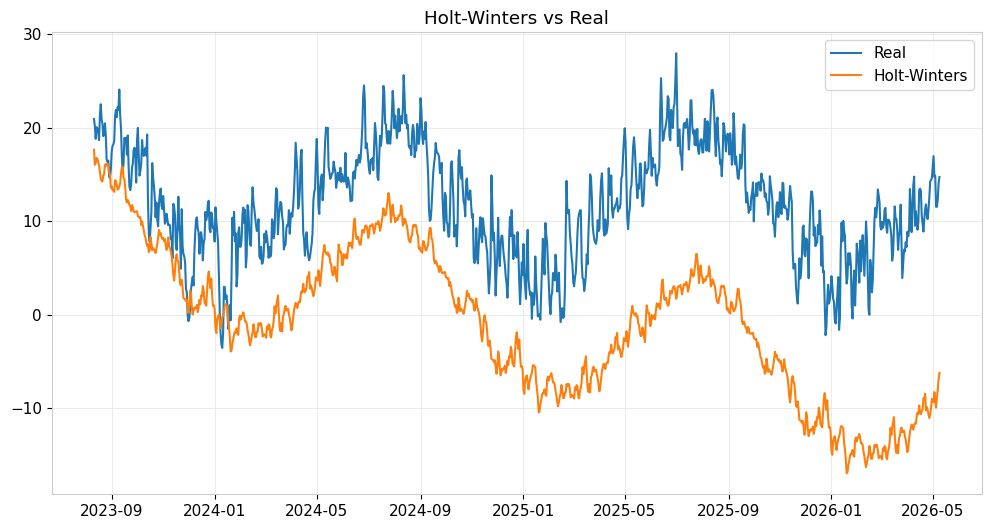

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(test['Date'], test['TempAvg'], label='Real')
plt.plot(test['Date'], test['HW_Prediction'], label='Holt-Winters')

plt.legend()
plt.title("Holt-Winters vs Real")
plt.show()

## GroepsOpdracht - train een model per locatie

In [60]:
import re
import sys
from pathlib import Path

import joblib
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'DWH').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from DWH.connection.connect import get_engine, getData


In [61]:
def safe_filename(name: str) -> str:
    """Zet een stationsnaam om naar een veilige bestandsnaam (lowercase, geen spaties)."""
    return re.sub(r'[^a-z0-9_]', '_', name.lower().strip())


In [62]:

def train_for_station(engine, station_naam: str, model_dir: Path) -> dict | None:
    """
    Haalt data op voor één station, traint een model en slaat het op.
    Geeft een dict met MAE-statistieken terug, of None bij onvoldoende data.
    """
    query = f"""
        SELECT
            d.FullDateAlternateKey AS Date,
            d.Month,
            d.DayOfYear,
            m.TempAvg
        FROM FactMeteo m
        JOIN DimDate d            ON m.DateKey           = d.DateKey
        JOIN DimWeatherStation ws ON m.WeatherStationKey = ws.WeatherstationID
        WHERE ws.Name = '{station_naam}'
        ORDER BY d.FullDateAlternateKey;
    """

    df = getData(engine, query)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').dropna()

    if len(df) < 30:
        print(f"  [SKIP] {station_naam}: te weinig data ({len(df)} rijen)")
        return None

    # Features
    df['Month']     = df['Date'].dt.month
    df['DayOfYear'] = df['Date'].dt.dayofyear

    split = int(len(df) * 0.8)
    train = df.iloc[:split]
    test  = df.iloc[split:]

    features = ['Month', 'DayOfYear']
    model = LinearRegression()
    model.fit(train[features], train['TempAvg'])

    # Evaluatie
    test = test.copy()
    test['Prediction']    = model.predict(test[features])
    test['NaiveForecast'] = test['TempAvg'].shift(7)
    valid = test.dropna()

    mae_model = mean_absolute_error(valid['TempAvg'], valid['Prediction'])
    mae_naive = mean_absolute_error(valid['TempAvg'], valid['NaiveForecast'])

    # Opslaan
    model_path = model_dir / f"model_gem_temp_{safe_filename(station_naam)}.pkl"
    joblib.dump(model, model_path)

    print(f"  [OK]   {station_naam:30s}  MAE model={mae_model:.2f}  MAE naive={mae_naive:.2f}  → {model_path.name}")
    return {"station": station_naam, "mae_model": mae_model, "mae_naive": mae_naive}


In [63]:
engine = get_engine()

# Haal alle stationsnamen op
stations_df = getData(engine, "SELECT Name FROM DimWeatherStation ORDER BY Name;")
stations = stations_df['Name'].tolist()
print(f"Gevonden stations: {len(stations)}\n")

model_dir = Path("../models/weer/v1")
model_dir.mkdir(parents=True, exist_ok=True)

resultaten = []
for naam in stations:
    resultaat = train_for_station(engine, naam, model_dir)
    if resultaat:
        resultaten.append(resultaat)

print(f"\n✅ {len(resultaten)} modellen getraind en opgeslagen in '{model_dir}'")

# Sla ook een overzicht op
pd.DataFrame(resultaten).to_csv(model_dir / "evaluatie.csv", index=False)
print("📄 Evaluatie opgeslagen in models/weer/evaluatie.csv")



Gevonden stations: 14

  [OK]   BEITEM                          MAE model=4.57  MAE naive=3.12  → model_gem_temp_beitem.pkl
  [OK]   BUZENOL                         MAE model=4.93  MAE naive=3.43  → model_gem_temp_buzenol.pkl
  [OK]   DE HAAN                         MAE model=2.06  MAE naive=2.29  → model_gem_temp_de_haan.pkl
  [OK]   DIEPENBEEK                      MAE model=4.94  MAE naive=3.49  → model_gem_temp_diepenbeek.pkl
  [OK]   DOURBES                         MAE model=4.99  MAE naive=3.61  → model_gem_temp_dourbes.pkl
  [OK]   ERNAGE                          MAE model=4.88  MAE naive=3.45  → model_gem_temp_ernage.pkl
  [OK]   HUMAIN                          MAE model=4.96  MAE naive=3.62  → model_gem_temp_humain.pkl
  [OK]   MELLE                           MAE model=4.66  MAE naive=3.22  → model_gem_temp_melle.pkl
  [OK]   MONT RIGI                       MAE model=5.04  MAE naive=3.79  → model_gem_temp_mont_rigi.pkl
  [OK]   RETIE                           MAE model=4.88  MA